<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/ML_In_Chem/Putting_it_together_Reg_1077167.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Boiling and Melting points Prediction** - Kwanda Mazibuko stdnr : 1077167

<div style="text-align: center;">
   <img src="https://raw.githubusercontent.com/kwanda2426/projects/main/ML_In_Chem/ML_and_Rdkit.png" >
</div>




# **Importing Libraries**

In [1]:
!pip -q install plotly scikit-learn tabulate pandas openpyxl rdkit pubchempy pandas

In [2]:
# Libraries for data loading, data manipulation and data visulisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
import plotly.express as px
from scipy.stats import kurtosis

from rdkit.Chem import Descriptors
from rdkit.Chem import Descriptors, rdMolDescriptors
import pubchempy as pcp
from rdkit import Chem
from rdkit.Chem import rdchem
from rdkit.Chem import Draw
from rdkit.Chem import Draw

#Feature engineering, selection and Model training
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
from tabulate import tabulate
from IPython.display import display


# **Data acquisition**

#### Front CSV File

In [3]:
# Reading data
url = "https://raw.githubusercontent.com/kwanda2426/projects/main/ML_In_Chem/hydrocarbons.csv"
df_1 = pd.read_csv(url)
df_1.head()

,Class of hydrocarbon,IUPAC name,Melting point,Boiling point,Density,Flash point,Autoignition temp,pubchem_id,smiles
0,Trimetylalkane,"2,2,4-Trimethylpentane",-107.0,99.0,0.69,NaN,396,10907,CC(C)CC(C)(C)C
1,Triaromatics,Phenanthrene,99.0,338.0,1.18,171,>450,995,C1=CC=C2C(=C1)C=CC3=CC=CC=C32
2,Triaromatics,Anthracene,216.0,341.0,1.2825,NaN,NaN,8418,C1=CC=C2C=C3C=CC=CC3=CC2=C1
3,Triaromatics,1-methylanthracene,86.0,342.0,1.04799,NaN,NaN,11884,CC1=CC=CC2=CC3=CC=CC=C3C=C12
4,Triaromatics,2-methylanthracene,209.0,340.0,1.8,NaN,NaN,11936,CC1=CC2=CC3=CC=CC=C3C=C2C=C1


#### Using RDKit - Molecular weight and Aromatic Rings

In [4]:
# Create new columns
df = df_1.copy()
df['Molecular_Weight'] = None
df['Aromatic_Rings'] = None

for i, smi in enumerate(df['smiles']):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        # Calculate molecular properties using RDKit
        mol_weight = Descriptors.MolWt(mol)
        aromatic_rings = rdMolDescriptors.CalcNumAromaticRings(mol)

        # Store results back into the DataFrame
        df.loc[i, 'Molecular_Weight'] = mol_weight
        df.loc[i, 'Aromatic_Rings'] = aromatic_rings

df['Molecular_Weight'] = pd.to_numeric(df['Molecular_Weight'], errors='coerce')
df['Aromatic_Rings'] = pd.to_numeric(df['Aromatic_Rings'], errors='coerce')

df.head()

,Class of hydrocarbon,IUPAC name,Melting point,Boiling point,Density,Flash point,Autoignition temp,pubchem_id,smiles,Molecular_Weight,Aromatic_Rings
0,Trimetylalkane,"2,2,4-Trimethylpentane",-107.0,99.0,0.69,NaN,396,10907,CC(C)CC(C)(C)C,114.232,0
1,Triaromatics,Phenanthrene,99.0,338.0,1.18,171,>450,995,C1=CC=C2C(=C1)C=CC3=CC=CC=C32,178.234,3
2,Triaromatics,Anthracene,216.0,341.0,1.2825,NaN,NaN,8418,C1=CC=C2C=C3C=CC=CC3=CC2=C1,178.234,3
3,Triaromatics,1-methylanthracene,86.0,342.0,1.04799,NaN,NaN,11884,CC1=CC=CC2=CC3=CC=CC=C3C=C12,192.261,3
4,Triaromatics,2-methylanthracene,209.0,340.0,1.8,NaN,NaN,11936,CC1=CC2=CC3=CC=CC=C3C=C2C=C1,192.261,3


In [5]:
df.columns

Index(['Class of hydrocarbon', 'IUPAC name', 'Melting point', 'Boiling point',
       'Density', 'Flash point', 'Autoignition temp', 'pubchem_id', 'smiles',
       'Molecular_Weight', 'Aromatic_Rings'],
      dtype='object')

- Model is built on Molecular wight and aromatic Rings. Hence we keep only those columns.

#### Final Dataset

In [6]:
# columns to keep
cols = ['Molecular_Weight', 'Aromatic_Rings','Melting point', 'Boiling point']
df_final = df[cols]

# **Data Preprocessing**

Data preprocessing is vital because it transforms messy raw data into a clean, consistent, and structured format, which is essential for accurate analysis and effective machine learning models.
Issues like missing values, inconsistencies, errors, and outliers are addressed to improve data quality,leads to more reliable and meaningful insights for decision-making and ultimately enhances the performance and accuracy of models.



#### Reviewing and Renaming Columns


In [7]:
# data columns
df_final.columns

Index(['Molecular_Weight', 'Aromatic_Rings', 'Melting point', 'Boiling point'], dtype='object')

- There are column names that have 'spaces'/'dashes' as separators. These 'spaces'/'dashes' are  replaced with an 'underscore' for readability and data for simplicity in data manipulation. Also, all variable names are converted to lowercase.

In [8]:
# Changing column names
df_final.columns = df_final.columns.str.replace(' ', '_', regex=False).str.lower()
df_final.head()

,molecular_weight,aromatic_rings,melting_point,boiling_point
0,114.232,0,-107.0,99.0
1,178.234,3,99.0,338.0
2,178.234,3,216.0,341.0
3,192.261,3,86.0,342.0
4,192.261,3,209.0,340.0


#### Dataset Dimensions and Variable Type

In [9]:
df = df_final.copy()

In [10]:
# Rows and Columns of data
print('Data has {} rows and {} Columns'.format(df.shape[0],df.shape[1]))
print('')
print('Data has the following variables:')
print('')
for i in df.columns:
  missing_values = 100*df[i].isnull().sum()/df.shape[0]
  print(i+', with {}% of missing data'.format(missing_values))
  print('')

Data has 194 rows and 4 Columns

Data has the following variables:

molecular_weight, with 0.0% of missing data

aromatic_rings, with 0.0% of missing data

melting_point, with 3.0927835051546393% of missing data

boiling_point, with 2.0618556701030926% of missing data



In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   molecular_weight  194 non-null    float64
 1   aromatic_rings    194 non-null    int64  
 2   melting_point     188 non-null    float64
 3   boiling_point     190 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 6.2 KB


- Dataset has some missing values which are less than 5%. These can be dropped.

In [12]:
df = df.dropna()

#### Summary Statistics and Variable Description

In [13]:
#describing numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
molecular_weight,186.0,175.559500,113.639165,16.043,106.168,154.297,211.85325,843.636
aromatic_rings,186.0,0.478495,0.919500,0.000,0.000,0.000,1.00000,4.000
melting_point,186.0,-30.994624,82.013018,-188.000,-95.000,-27.500,15.00000,256.000
boiling_point,186.0,211.118280,138.702080,-162.000,115.500,206.500,300.25000,625.000


# **Feature Engineering**

This is a vital step where data is explored and then transformed from raw data into features that enhance machine learning model performance, accuracy, and generalization by making patterns more discernable.

### **Exploratory Data Analysis**

This method is meant to uncover the underlying structure of a data set and is important for a company because it exposes trends, patterns, and relationships that are not readily apparent.

#### **Distributions**
This is meant to discover :
- Distribution of features to decide on the kind of scaling required

#### Target Variables Distribution - Boiling Point

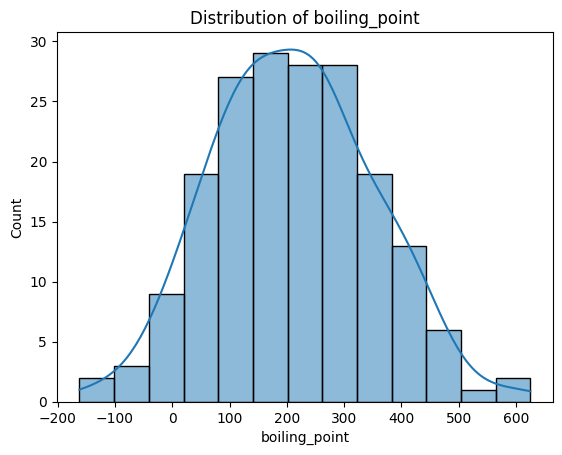

In [14]:
df_1 = df.copy()
sns.histplot(df_1['boiling_point'], kde = True)
plt.title('Distribution of boiling_point')
plt.show()

#### **Obsevations**

- Since Boiling Point is normally distributed, models like linear regression, ridge/lasso regression, and tree-based models will likely perform well without needing target transformations.

- No need to do log or power transforms to “normalize” the target, unlike skewed data. Standardisation should suffice.

#### Target Variables Distribution - Melting Point

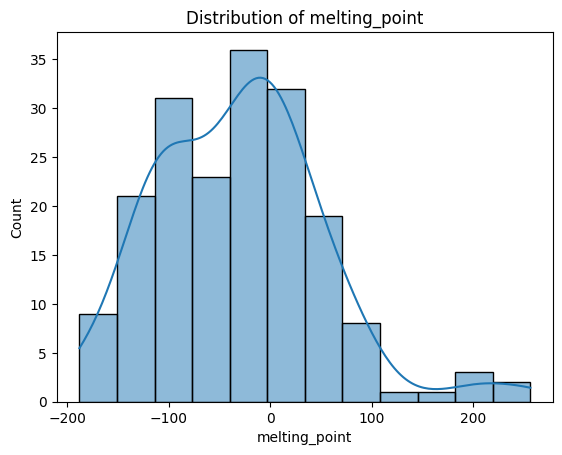

In [15]:
df_1 = df.copy()
sns.histplot(df_1['melting_point'], kde = True)
plt.title('Distribution of melting_point')
plt.show()

#### **Obsevations**
- Melting Point is more variable than Boiling Point and might be influenced by subtle molecular features (e.g., branching, polarity, crystal packing).

- Because it’s not perfectly normal, some very low or very high Melting Point compounds exist, but they’re not extreme.

#### Correlation

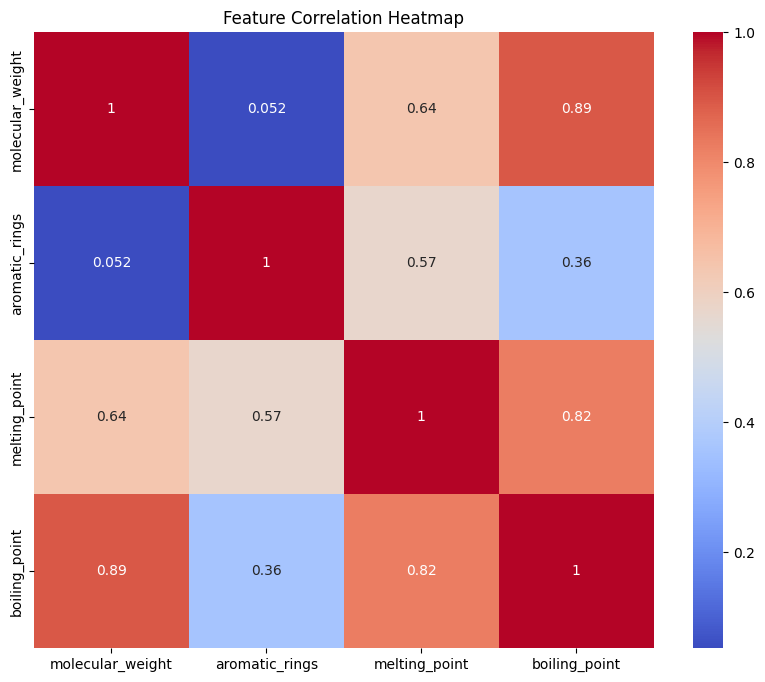

In [16]:
df_temp = df.copy()
plt.figure(figsize = (10,8))
sns.heatmap(df_temp.corr(), annot = True,cmap = 'coolwarm' )
plt.title('Feature Correlation Heatmap')
plt.show()

In [17]:
df_temp.corr()

,molecular_weight,aromatic_rings,melting_point,boiling_point
molecular_weight,1.000000,0.051938,0.639573,0.893102
aromatic_rings,0.051938,1.000000,0.569314,0.359090
melting_point,0.639573,0.569314,1.000000,0.823502
boiling_point,0.893102,0.359090,0.823502,1.000000


#### **Observations**:

**Molecular weight**

- Correlation with Boiling Point: 0.893 - very strong positive :

This makes sense: heavier hydrocarbons generally boil at higher temperatures.
This means that molecular weight will likely be the most important feature for predicting Boiling Point.

- Correlation with Melting Point: 0.640 - moderately strong positive :
Molecular weight also matters for melting point, but less so than for Boiling Point.

**Aromatic rings**

- Correlation with Melting Point: 0.569 - moderate positive

Aromatic rings increase rigidity and packing efficiency results in higher Melting Point.

- Correlation with Boiling Point: 0.359 - weak-to-moderate positive

Rings slightly raise Boiling Point, but their effect is smaller than molecular weight.

Overall: aromatic rings are more important for Melting Point prediction than Boiling Point.

**Melting point vs boiling point**

Correlation 0.824 - strong positive

Compounds with high melting points generally also have high boiling points.

**Key takeaway**:

- For Boiling Point: molecular weight dominates, aromatic rings contribute a little.

- For Melting Point: both molecular weight and aromatic rings are useful, roughly similar importance.

#### Variables Distribution

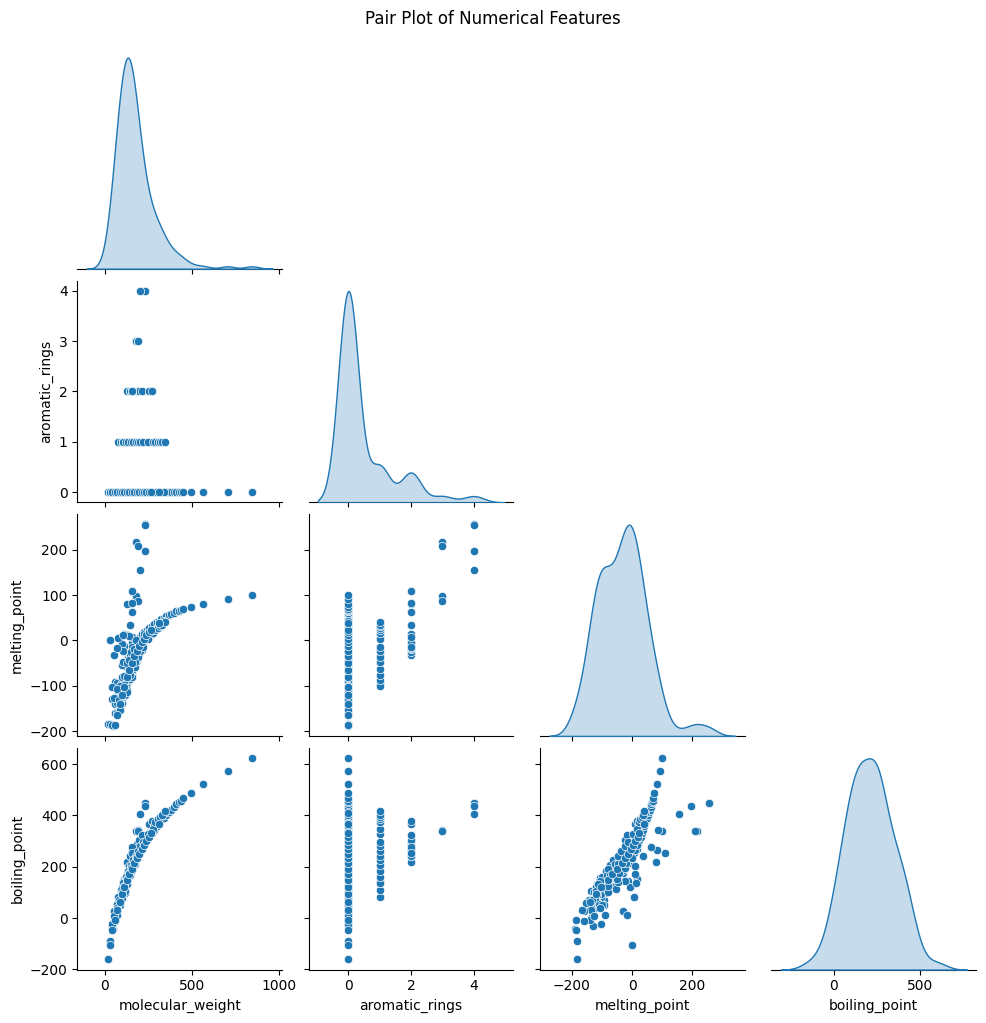

In [18]:
# columns for the pair plot
df_1 = df.copy()
numerical_cols = df_1.columns
# Create the pair plot
sns.pairplot(df_1[numerical_cols], diag_kind = 'kde', corner = True)
plt.suptitle('Pair Plot of Numerical Features', y = 1.02)
plt.show()



- Aromatic Rings seem to be discrete. This means that they exist in certain ranges.

- Boiling point and melting point seem to increase with an increase in moelecular weight.
- Boiling point and melting point seem to increase with each other, confirming what was observed through the correlation matrix.

#### skewness/kurtosis

In [19]:
df.columns

Index(['molecular_weight', 'aromatic_rings', 'melting_point', 'boiling_point'], dtype='object')

In [20]:
df_temp = df.copy()
features = df_temp.drop(['melting_point', 'boiling_point'], axis = 1)

# Calculate kurtosis for each feature
kurtosis_values = {
    'Feature': [],
    'Kurtosis': [],
    'Interpretation': [],
    'Kurtosis Value Interpretation': []
}

k_meaning = '<3: Light tails (fewer outliers), ~3: Normal distribution, >3: Heavy tails (more outliers)'

for col in features.columns:
    k = kurtosis(df_temp[col], fisher=True, bias=False)
    kurtosis_values['Feature'].append(col)
    kurtosis_values['Kurtosis'].append(round(k, 3))
    kurtosis_values['Kurtosis Value Interpretation'].append(k_meaning)
    if k > 3:
        interpretation = "Heavy tails (many outliers)"
    elif k < 3:
        interpretation = "Light tails (few outliers)"
    else:
        interpretation = "Normal-like tails"
    kurtosis_values['Interpretation'].append(interpretation)

# Display the results
kurtosis_df = pd.DataFrame(kurtosis_values)
print(tabulate(kurtosis_df, headers='keys', tablefmt='grid'))

+----+------------------+------------+-----------------------------+--------------------------------------------------------------------------------------------+
|    | Feature          |   Kurtosis | Interpretation              | Kurtosis Value Interpretation                                                              |
+====+==================+============+=============================+============================================================================================+
|  0 | molecular_weight |      8.535 | Heavy tails (many outliers) | <3: Light tails (fewer outliers), ~3: Normal distribution, >3: Heavy tails (more outliers) |
+----+------------------+------------+-----------------------------+--------------------------------------------------------------------------------------------+
|  1 | aromatic_rings   |      3.883 | Heavy tails (many outliers) | <3: Light tails (fewer outliers), ~3: Normal distribution, >3: Heavy tails (more outliers) |
+----+------------------+---

These features exhibit heavy-tailed distributions (kurtosis > 3), indicating high outlier risk, so a scaler robust to outliers is needed. The RobustScaler would be suitable for feature scaling.

#### Feature Scaling

it prevents features with larger numerical values from disproportionately influencing the model's learning.
When features have vastly different ranges (e.g., one feature ranges from 0-10 and another from 0-10,000), the model can become biased toward the feature with the larger magnitude, simply because its values are larger.

In [21]:
df.head()

,molecular_weight,aromatic_rings,melting_point,boiling_point
0,114.232,0,-107.0,99.0
1,178.234,3,99.0,338.0
2,178.234,3,216.0,341.0
3,192.261,3,86.0,342.0
4,192.261,3,209.0,340.0


In [22]:
# features and target variable
df_final = df.copy()
X = df.drop(['melting_point', 'boiling_point'], axis = 1)
y = df[['melting_point', 'boiling_point']]

# Initialize the scaler
scaler = RobustScaler()
# apply scaler to predictor variables
X_scaled = scaler.fit_transform(X)

#### Data Split
Splitting data into training and testing sets is essential to evaluate a model's performance on new, unseen data and prevent overfitting. The training set teaches the model patterns, while the untouched test set provides an unbiased assessment of its generalisation ability, ensuring the model performs accurately in real-world scenarios rather than just on the data it learned from.


In [23]:
 # Train- test Split: 80% train and 20% test -- random state = 42, ensure the reproducibility of the data split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 42)

# **Model selection**

1. **Support Vector Regression (SVR)**
 :  is a strong choice for this solubility prediction task, especially with 1,128 data points. SVR handles nonlinear relationships well using kernel functions like RBF, which is ideal since molecular features mostly interact in complex ways. It is also robust to overfitting in smaller datasets because of its optimization capability, and it performs well when features vary in scale. With these different features and moderate dataset size, SVR offers a balance of flexibility and generalization that is suitable for this task.

 2. **Random Forest Regressor** : is a strong candidate for your solubility prediction task with 1,128 rows, as it excels at capturing nonlinear relationships and complex feature interactions without requiring extensive preprocessing. It is robust to outliers and multicollinearity, which is valuable given the variability of these features in this dataset. In addition, Random Forest provides built-in feature importance scores, helping to identify which features mostly influence solubility. Its ensemble nature also reduces overfitting, making it well-suited for medium-sized datasets.

 3. **Linear Regression** : is a good model for this solubility prediction task with 1,128 rows. It is simple, fast to implement. It is easy to interpret, this means that it ideal for benchmarking and understanding how each molecular feature contributes to solubility. If the relationships between features and solubility are approximately linear, it can perform well. Even when the fit is not perfect, Linear Regression helps reveal multicollinearity and feature significance, guiding feature selection and engineering for more complex models.

# **Model Training and Evaluation**

In this step, data is training data fed to the model. Training a model is essential because it allows the algorithm to learn patterns and relationships from data so it can make accurate predictions or decisions on new, unseen inputs. Without training, the model would have no understanding of how features relate to outcomes.

Models are put inside a MultiOutputRegressor since we are predicting melting and boiling point. When models, namely SVR, RandomForestRegressor, or LinearRegression are wrapped inside MultiOutputRegressor, scikit-learn automatically fits one separate model per target variable.

In [24]:
# Initiate Models
models = {
    'SVR': MultiOutputRegressor(SVR()),
    'Random Forest': MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42)),
    'Linear Regression': MultiOutputRegressor(LinearRegression())
}

# Model Training and evaluation
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Metrics
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Save results
    results.append({
        'Model': name,
        'Train MSE': train_mse,
        'Test MSE': test_mse,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R²': train_r2,
        'Test R²': test_r2
    })

# Results
results_df = pd.DataFrame(results)

# **Model Evaluation Results**

Models are evaluated using the validation dataset. Validating these trained models is crucial because it helps identify which one performs best to unseen data—without touching the test set. This step acts like a rehearsal before the final performance: it reveals whether the model is overfitting (memorising the training data) or underfitting (failing to learn enough). By evaluating on the validation set, we can select the most promising model and fine-tune its hyperparameters, ensuring that when it is finally tested, the true predictive power is measured — not just luck or overtraining.

### **Regression Evaluation Metrics**

 **Mean Squared Error (MSE)** - it measures the average of the squared differences between predicted and actual values. it is useful because it penalises larger errors more heavily, which is helpful when we want to reduces prediction errors.Since solubility can vary widely, MSE helps ensure that the  model does not perform badly on extreme values.

**Root Mean Squared Error (RMSE)** - it measures the square root of MSE. It puts error back in the same units as the target variable. it is useful because it is easier to interpret than MSE because it says that, on average, how far off the predictions are in terms of solubility. In this
case RMSE gives a direct sense of how accurate the solubility predictions are.

**Coefficient of Determination (R-Squared)** - it measures the proportion of variance in the target variable explained by the model. This is useful because it tells us how well the features explain solubility. A higher R-suared would mean our molecular features are capturing the factors that influence solubility well.

In essence, MSE and RMSE quantify prediction accuracy and R-squared explains model effectiveness in capturing underlying patterns.

In [25]:
# Evaluation Results
print(tabulate(results_df, headers='keys', tablefmt='grid'))

+----+-------------------+-------------+------------+--------------+-------------+------------+-----------+
|    | Model             |   Train MSE |   Test MSE |   Train RMSE |   Test RMSE |   Train R² |   Test R² |
+====+===================+=============+============+==============+=============+============+===========+
|  0 | SVR               |    9265.5   |    8846.82 |      96.2575 |     94.0575 |   0.290754 |  0.307296 |
+----+-------------------+-------------+------------+--------------+-------------+------------+-----------+
|  1 | Random Forest     |     396.012 |    1021.67 |      19.9    |     31.9636 |   0.9452   |  0.84648  |
+----+-------------------+-------------+------------+--------------+-------------+------------+-----------+
|  2 | Linear Regression |    2066.74  |    1815.45 |      45.4614 |     42.6081 |   0.794264 |  0.803421 |
+----+-------------------+-------------+------------+--------------+-------------+------------+-----------+


 **Model Perfomance**

- SVR is underfitting badly. It fails to capture relationships in the data, likely because the default kernel or parameters are not suitable for this data scale or patterns.

- Random Forest Very low error on training, moderate on test. Predictions are within ~32 units on test set. Explains ~85% of variance on unseen data. This is Excellent generalisation.


- Linear Regression Moderate prediction error. Explains about 80% of variance which is a decent fit. Linear Regression does okay but not as well as Random Forest. It performs slightly better on the test set than on the train (so, no overfitting), but it misses nonlinear patterns that the Random Forest captures.

Overall, Random Forest is the best performer. High R-squared means the model captures most of the signal. Small train - test gap (0.95 - 0.85) means slight overfitting but still in an acceptable range. RMSE is lowest among all models, so predictions are most accurate.

### Visualising Prediction of the Random Forest Model on Test data

In [30]:
# Example: inspect predictions for Random Forest
rf_model = models['Random Forest']
y_pred_test = rf_model.predict(X_test)

# Combine actual vs predicted into a DataFrame
pred_comparison = pd.DataFrame({
    'Actual_melting_point': y_test['melting_point'],
    'Predicted_melting_point': y_pred_test[:, 0],
    'Actual_boiling_point': y_test['boiling_point'],
    'Predicted_boiling_point': y_pred_test[:, 1]
})

pred_comparison = pred_comparison.reset_index(drop=True)


# Show first few predictions
print(tabulate(pred_comparison.head(10), headers='keys', tablefmt='grid'))

+----+------------------------+---------------------------+------------------------+---------------------------+
|    |   Actual_melting_point |   Predicted_melting_point |   Actual_boiling_point |   Predicted_boiling_point |
+====+========================+===========================+========================+===========================+
|  0 |                    -63 |                  -52.7886 |                    226 |                  204.377  |
+----+------------------------+---------------------------+------------------------+---------------------------+
|  1 |                    -19 |                  -52.1323 |                    215 |                  222.918  |
+----+------------------------+---------------------------+------------------------+---------------------------+
|  2 |                   -185 |                 -113.034  |                     -6 |                    4.03   |
+----+------------------------+---------------------------+------------------------+------------

- These are the first 10 actual vs test predictions of Melting point and Boiling point.

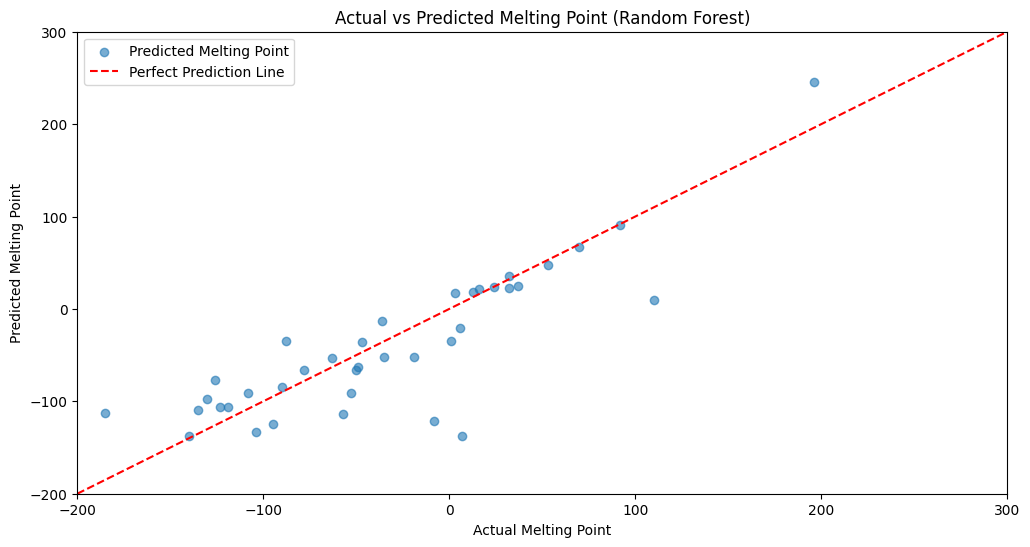

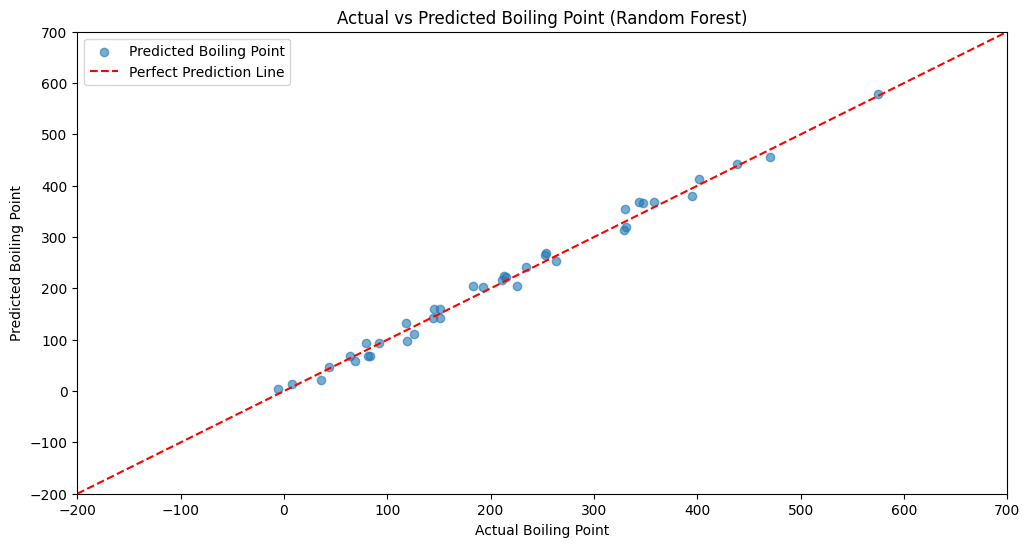

In [34]:
plt.figure(figsize=(12, 6))

# Scatter plot for Melting Point
plt.scatter(pred_comparison['Actual_melting_point'], pred_comparison['Predicted_melting_point'], alpha=0.6, label='Predicted Melting Point')
plt.xlabel('Actual Melting Point')
plt.ylabel('Predicted Melting Point')
plt.title('Actual vs Predicted Melting Point (Random Forest)')
plt.plot([-200, 300], [-200, 300], color='red', linestyle='--', label='Perfect Prediction Line') # Add a diagonal line for perfect prediction
plt.xlim([-200, 300])
plt.ylim([-200, 300])
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))

# Scatter plot for Boiling Point
plt.scatter(pred_comparison['Actual_boiling_point'], pred_comparison['Predicted_boiling_point'], alpha=0.6, label='Predicted Boiling Point')
plt.xlabel('Actual Boiling Point')
plt.ylabel('Predicted Boiling Point')
plt.title('Actual vs Predicted Boiling Point (Random Forest)')
plt.plot([-200, 700], [-200, 700], color='red', linestyle='--', label='Perfect Prediction Line') # Add a diagonal line for perfect prediction
plt.xlim([-200, 700])
plt.ylim([-200, 700])
plt.legend()
plt.show()

- The model performs very well for mid- and high-range melting points (0 and above).
- Larger errors occur for very low temperatures (below -100). This suggests the model might not fully capture nonlinear behavior at extremely low melting points (possibly due to data sparsity or limited feature coverage there).

- Boiling point predictions are consistently strong — most are within +-20 of actual values.
- There is no obvious systematic bias (model does not always over- or underpredict). Accuracy is quite stable across low and high ranges.

# **Challenges and Potential Improvements**

 **Challenges Encountered**

- Limited Dataset Size (< 200 rows) :
With fewer than 200 observations, the model ability to generalise is limited. Small datasets make it harder for models (especially flexible ones like Random Forests or SVRs) to learn subtle nonlinear relationships. There is a higher risk of overfitting to the training data or underrepresenting certain regions of the feature space — for instance, extreme melting points (below -100) showed higher prediction errors, likely due to fewer examples in that range.

- Uneven Feature – Target Relationships : Melting and boiling points are influenced by multiple complex chemical factors (e.g., intermolecular forces, molecular weight, polarity). The two features do not fully capture these relationships, hence the model struggle to make precise predictions, particularly for compounds outside the dominant patterns.

- Scale Sensitivity (SVR and Linear Models) : Support Vector Regression and Linear Regression are sensitive to feature scaling. If one scaling method is used instead of the other, these result in poor performance. Random Forests are less affected by scale, which is consistent with its much stronger performance.

- Target Range and Nonlinearity :
Physical properties like melting/boiling points often have nonlinear and interdependent patterns. Linear regression cannot capture these nonlinearities effectively.

The Random Forest handled them much better, but performance still drops at the extremes, suggesting that the model has not seen enough examples in those regions.

**Potential Improvements**

- Data Augmentation or Expansion : If possible, more samples can be collected or augmented with the existing ones through simulation or domain-specific estimations. Even doubling the sample size could dramatically improve model stability and coverage of extreme values.

- Hyperparameter Tuning : For Random Forest, adjust parameters such as n_estimators, max_depth, and min_samples_split using GridSearchCV or RandomizedSearchCV. For SVR, tune C, epsilon, and gamma — this can substantially improve fit on small datasets.

- Cross-Validation for Robust Evaluation : Instead of a single train–test split, use k-fold cross-validation (e.g., KFold(n_splits=5)), which makes better use of limited data and provides a more stable estimate of performance.








# **Conclusion**

Despite the small dataset, the Random Forest model achieved strong predictive accuracy (R² ≈ 0.85) and realistic predictions for both melting and boiling points.
The main limitations come from data scarcity and nonlinear complexity rather than model inadequacy.
Future improvements should focus on enriching features, scaling inputs, and fine-tuning models to improve predictions at the data extremes.

What the model shows:
- Strong predictive performance on a chemically meaningful dataset.
- Alignment with domain knowledge, reinforcing model credibility.

**What can be done to further test the model**:

- External Validation with a New Dataset :
Tuned model can be applied to a completely different dataset or  from a different chemical library.
- Uncertainty Quantification :
Techniques like Quantile Regression Forests or Prediction Intervals can be used to estimate confidence bounds around each prediction.
- Domain-Specific Feature Enrichment :
Incorporate cheminformatics features like LogP, TPSA, or Lipinski’s Rule of Five indicators. These are known to correlate with solubility and may improve interpretability and performance.


# **References**


- Breiman, L., 2001. Random forests. Machine Learning, 45(1), pp.5–32.

- Hastie, T., Tibshirani, R. and Friedman, J., 2009. The Elements of Statistical Learning: Data Mining, Inference, and Prediction. 2nd ed. New York: Springer.
- Landrum, G., 2023. RDKit: Open-source cheminformatics. Available at: https://www.rdkit.org
 [Accessed 31 October 2025].
- Todeschini, R. and Consonni, V., 2009. Molecular Descriptors for Chemoinformatics. 2nd ed. Weinheim: Wiley-VCH.
- Copilot.

